
# Olist Brazilian E-Commerce Data Analysis

This notebook processes and analyzes the Brazilian E-Commerce Public Dataset by Olist.

## Objectives

- Load and inspect the dataset
- Clean and combine the individual tables
- Analyze orders, customers, sellers, products, payments, and reviews
- Study revenue and sales trends
- Analyze delivery performance
- Identify top product categories and sellers
- Export a processed analytical dataset


In [1]:

# Uncomment these commands if the packages are not installed

# !pip install pandas numpy matplotlib seaborn scikit-learn kaggle


In [2]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

Matplotlib created a temporary config/cache directory at /var/folders/53/sdyb1p3j4_7_mzk4t2x3r8c00000gq/T/matplotlib-ltpjwrun because the default path (/Users/redalpha04/.matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.



## Dataset setup

Download the dataset from Kaggle:

<https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce>

Extract the CSV files into a directory such as:

```text
data/
├── olist_customers_dataset.csv
├── olist_geolocation_dataset.csv
├── olist_order_items_dataset.csv
├── olist_order_payments_dataset.csv
├── olist_order_reviews_dataset.csv
├── olist_orders_dataset.csv
├── olist_products_dataset.csv
├── olist_sellers_dataset.csv
└── product_category_name_translation.csv



---------------------------------------------------------------------
Configuration
---------------------------------------------------------------------


In [ ]:

DATA_DIR = "data/olist"

csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
sorted(csv_files)


['data/archive/olist_customers_dataset.csv',
 'data/archive/olist_geolocation_dataset.csv',
 'data/archive/olist_order_items_dataset.csv',
 'data/archive/olist_order_payments_dataset.csv',
 'data/archive/olist_order_reviews_dataset.csv',
 'data/archive/olist_orders_dataset.csv',
 'data/archive/olist_products_dataset.csv',
 'data/archive/olist_sellers_dataset.csv',
 'data/archive/product_category_name_translation.csv']


---------------------------------------------------------------------
Load files
---------------------------------------------------------------------


In [4]:

def load_csv(filename):
    path = os.path.join(DATA_DIR, filename)
    return pd.read_csv(path)

customers = load_csv("olist_customers_dataset.csv")
geolocation = load_csv("olist_geolocation_dataset.csv")
order_items = load_csv("olist_order_items_dataset.csv")
order_payments = load_csv("olist_order_payments_dataset.csv")
order_reviews = load_csv("olist_order_reviews_dataset.csv")
orders = load_csv("olist_orders_dataset.csv")
products = load_csv("olist_products_dataset.csv")
sellers = load_csv("olist_sellers_dataset.csv")
category_translation = load_csv("product_category_name_translation.csv")

datasets = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation,
}

for name, dataframe in datasets.items():
    print(f"{name:20} rows={len(dataframe):8,} columns={len(dataframe.columns)}")


customers            rows=  99,441 columns=5
geolocation          rows=1,000,163 columns=5
order_items          rows= 112,650 columns=7
order_payments       rows= 103,886 columns=5
order_reviews        rows=  99,224 columns=7
orders               rows=  99,441 columns=8
products             rows=  32,951 columns=9
sellers              rows=   3,095 columns=4
category_translation rows=      71 columns=2



---------------------------------------------------------------------
Inspection
---------------------------------------------------------------------


In [5]:

for name, dataframe in datasets.items():
    print(f"{name.upper()}")
    display(dataframe.head(3))
    print(dataframe.dtypes)


CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object
GEOLOCATION


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP


geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object
ORDER_ITEMS


...

product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object
SELLERS


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object
dtype: object
CATEGORY_TRANSLATION


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


product_category_name            object
product_category_name_english    object
dtype: object


In [6]:

missing_values = pd.DataFrame({
    "table": list(datasets.keys()),
    "missing_values": [
        dataframe.isna().sum().sum()
        for dataframe in datasets.values()
    ]
})

missing_values


,table,missing_values
0,customers,0
1,geolocation,0
2,order_items,0
3,order_payments,0
4,order_reviews,145903
5,orders,4908
6,products,2448
7,sellers,0
8,category_translation,0


In [7]:

def missing_summary(dataframe):
    result = pd.DataFrame({
        "missing_count": dataframe.isna().sum(),
        "missing_percentage": dataframe.isna().mean() * 100
    })
    return result.sort_values("missing_percentage", ascending=False)

missing_summary(orders)


,missing_count,missing_percentage
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899
order_id,0,0.000000
customer_id,0,0.000000
order_status,0,0.000000
order_purchase_timestamp,0,0.000000
order_estimated_delivery_date,0,0.000000



---------------------------------------------------------------------
Date conversion
---------------------------------------------------------------------


In [8]:

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_creation_date",
    "review_answer_timestamp"
]

for dataframe in [orders, order_reviews]:
    for column in date_columns:
        if column in dataframe.columns:
            dataframe[column] = pd.to_datetime(dataframe[column], errors="coerce")

orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB



---------------------------------------------------------------------
Remove duplicates
---------------------------------------------------------------------


In [9]:

for name, dataframe in datasets.items():
    duplicate_count = dataframe.duplicated().sum()
    print(f"{name:20}: {duplicate_count:,} duplicate rows")


customers           : 0 duplicate rows
geolocation         : 261,831 duplicate rows
order_items         : 0 duplicate rows
order_payments      : 0 duplicate rows
order_reviews       : 0 duplicate rows
orders              : 0 duplicate rows
products            : 0 duplicate rows
sellers             : 0 duplicate rows
category_translation: 0 duplicate rows



---------------------------------------------------------------------
Translate product categories
---------------------------------------------------------------------


In [10]:

products = products.merge(
    category_translation,
    how="left",
    on="product_category_name"
)

products["product_category_name_english"] = (
    products["product_category_name_english"]
    .fillna(products["product_category_name"])
    .fillna("unknown")
)

products[[
    "product_id",
    "product_category_name",
    "product_category_name_english"
]].head()


,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares



---------------------------------------------------------------------
Build analytical dataset
---------------------------------------------------------------------




Create an analytical order-item dataset
The main analytical table combines:

Orders
Order items
Products
Sellers
Customers
Payments
Reviews 

In [12]:

# Aggregate payment information to the order level
payment_summary = (
    order_payments
    .groupby("order_id", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max"),
        payment_types=("payment_type", lambda values: ", ".join(sorted(set(values))))
    )
)

# Aggregate review information to the order level
review_summary = (
    order_reviews
    .groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "mean"),
        review_count=("review_id", "nunique")
    )
)

# Combine order-level tables
order_level = (
    orders
    .merge(customers, on="customer_id", how="left")
    .merge(payment_summary, on="order_id", how="left")
    .merge(review_summary, on="order_id", how="left")
)

# Combine order items with products and sellers
order_item_level = (
    order_items
    .merge(products, on="product_id", how="left")
    .merge(
        sellers,
        on="seller_id",
        how="left",
        suffixes=("", "_seller")
    )
)

# Final analytical dataset
order_data = order_item_level.merge(
    order_level,
    on="order_id",
    how="left",
    suffixes=("", "_order")
)

order_data.shape


(112650, 35)


---------------------------------------------------------------------
Feature engineering
---------------------------------------------------------------------


In [13]:

order_data["item_total"] = order_data["price"] + order_data["freight_value"]

order_data["purchase_month"] = (
    order_data["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

order_data["purchase_date"] = (
    order_data["order_purchase_timestamp"]
    .dt.date
)

order_data["delivery_days"] = (
    order_data["order_delivered_customer_date"]
    - order_data["order_purchase_timestamp"]
).dt.total_seconds() / 86400

order_data["estimated_delivery_days"] = (
    order_data["order_estimated_delivery_date"]
    - order_data["order_purchase_timestamp"]
).dt.total_seconds() / 86400

order_data["delivery_delay_days"] = (
    order_data["order_delivered_customer_date"]
    - order_data["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

order_data["is_late"] = order_data["delivery_delay_days"] > 0

order_data["is_cancelled"] = (
    order_data["order_status"].str.lower() == "canceled"
)

order_data["is_delivered"] = (
    order_data["order_status"].str.lower() == "delivered"
)

order_data.head()


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_installments,payment_types,review_score,review_count,item_total,purchase_month,purchase_date,delivery_days,estimated_delivery_days,delivery_delay_days,is_late,is_cancelled,is_delivered
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,27277,volta redonda,SP,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,72.19,2.0,credit_card,5.0,1.0,72.19,2017-09,2017-09-13,7.614421,15.625671,-8.011250,False,False,True
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,3471,sao paulo,SP,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,259.83,3.0,credit_card,4.0,1.0,259.83,2017-04,2017-04-26,16.216181,18.546458,-2.330278,False,False,True
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,37564,borda da mata,MG,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,216.87,5.0,credit_card,5.0,1.0,216.87,2018-01,2018-01-14,7.948437,21.393391,-13.444954,False,False,True
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,14403,franca,SP,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,25.78,2.0,credit_card,4.0,1.0,25.78,2018-08,2018-08-08,6.147269,11.582928,-5.435660,False,False,True
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools,87900,loanda,PR,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,218.04,3.0,credit_card,5.0,1.0,218.04,2017-02,2017-02-04,25.114352,40.418160,-15.303808,False,False,True



---------------------------------------------------------------------
Order overview
--------------------------------------------------------------------


In [14]:

overview = {
    "unique_orders": order_data["order_id"].nunique(),
    "unique_customers": order_data["customer_unique_id"].nunique(),
    "unique_sellers": order_data["seller_id"].nunique(),
    "unique_products": order_data["product_id"].nunique(),
    "total_revenue": order_data["payment_value"].sum(),
    "average_order_value": (
        order_data.groupby("order_id")["payment_value"]
        .first()
        .mean()
    ),
    "average_review_score": order_data["review_score"].mean()
}

pd.Series(overview)


unique_orders           9.866600e+04
unique_customers        9.542000e+04
unique_sellers          3.095000e+03
unique_products         3.295100e+04
total_revenue           2.030813e+07
average_order_value     1.606069e+02
average_review_score    4.033128e+00
dtype: float64


---------------------------------------------------------------------
Order status
---------------------------------------------------------------------


,order_status,orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


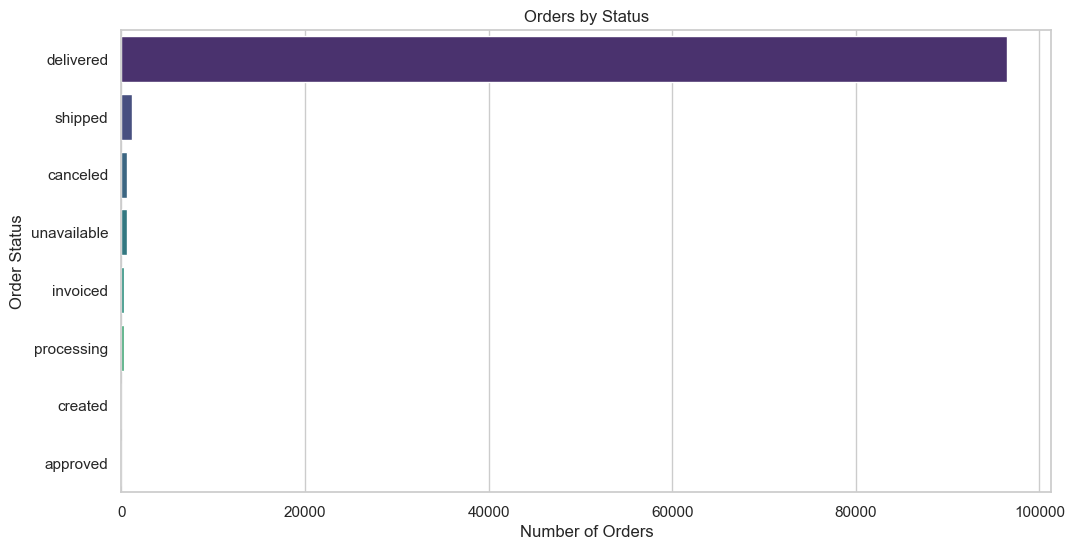

In [15]:

order_status = (
    orders["order_status"]
    .value_counts()
    .rename_axis("order_status")
    .reset_index(name="orders")
)

display(order_status)

sns.barplot(
    data=order_status,
    x="orders",
    y="order_status",
    palette="viridis"
)

plt.title("Orders by Status")
plt.xlabel("Number of Orders")
plt.ylabel("Order Status")
plt.show()



---------------------------------------------------------------------
Monthly revenue
---------------------------------------------------------------------


,purchase_month,revenue,orders,customers,average_order_value
0,2016-09,347.52,3,3,115.840000
1,2016-10,73914.58,308,305,239.982403
2,2016-12,19.62,1,1,19.620000
3,2017-01,187779.41,789,755,237.996717
4,2017-02,344134.79,1733,1708,198.577490


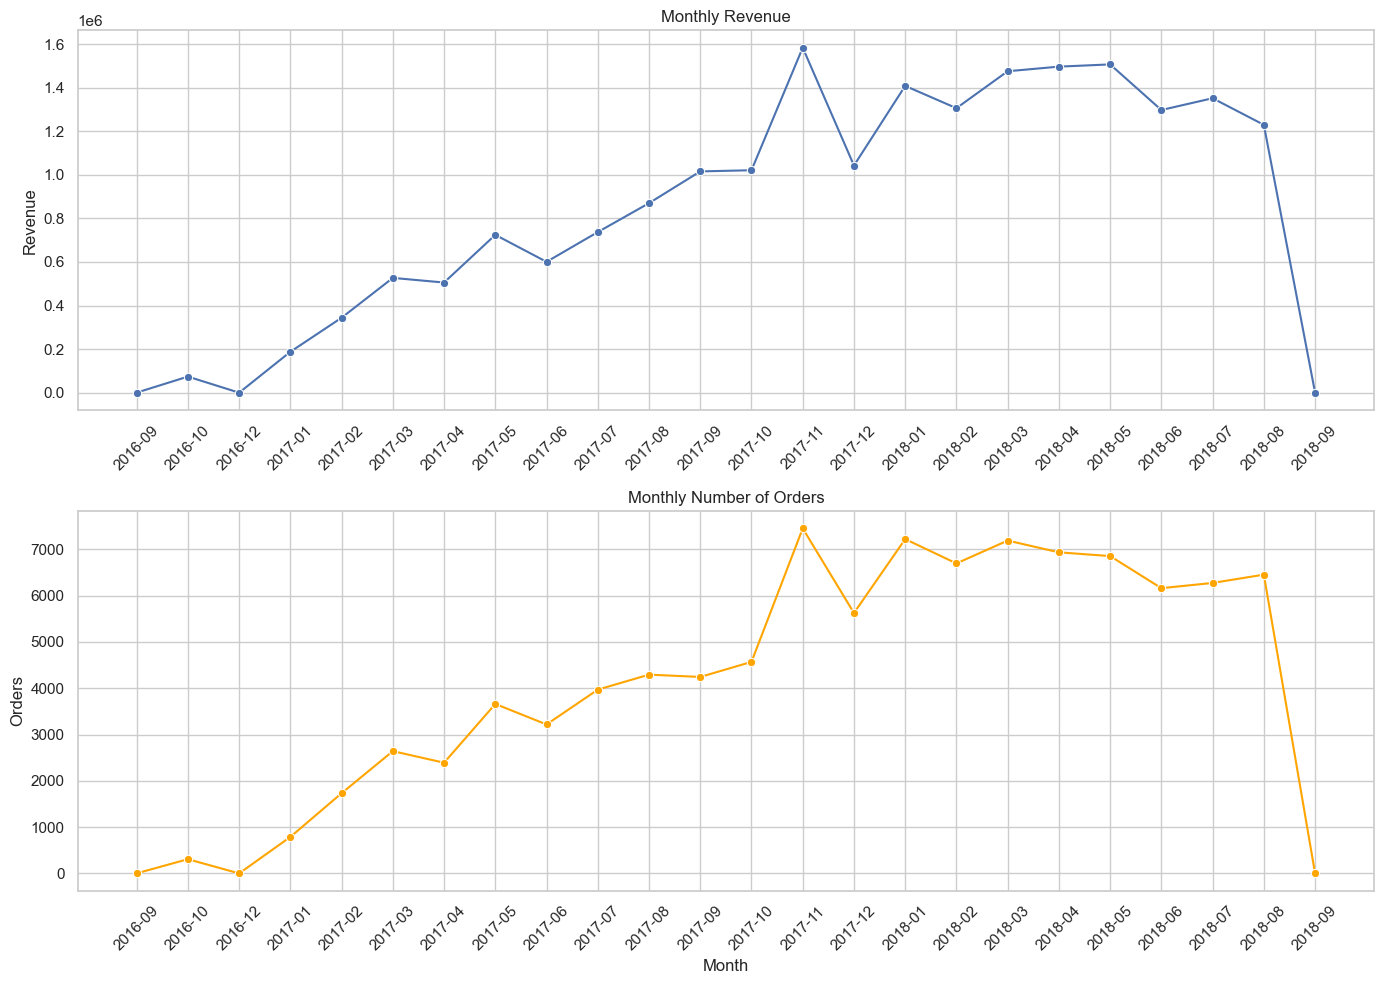

In [16]:

monthly_revenue = (
    order_data
    .groupby("purchase_month", as_index=False)
    .agg(
        revenue=("payment_value", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique")
    )
)

monthly_revenue["average_order_value"] = (
    monthly_revenue["revenue"] /
    monthly_revenue["orders"]
)

display(monthly_revenue.head())

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

sns.lineplot(
    data=monthly_revenue,
    x="purchase_month",
    y="revenue",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("Monthly Revenue")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_xlabel("")
axes[0].set_ylabel("Revenue")

sns.lineplot(
    data=monthly_revenue,
    x="purchase_month",
    y="orders",
    marker="o",
    ax=axes[1],
    color="orange"
)

axes[1].set_title("Monthly Number of Orders")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Orders")

plt.tight_layout()
plt.show()



---------------------------------------------------------------------
Product categories
---------------------------------------------------------------------


,product_category_name_english,revenue,items_sold,orders
7,bed_bath_table,1712553.67,11115,9417
43,health_beauty,1657373.12,9670,8836
15,computers_accessories,1585330.45,7827,6689
39,furniture_decor,1430176.39,8334,6449
73,watches_gifts,1429216.68,5991,5624
67,sports_leisure,1392127.56,8641,7720
49,housewares,1094758.13,6964,5884
5,auto,852294.33,4235,3897
42,garden_tools,838280.75,4347,3518
20,cool_stuff,779698.00,3796,3632


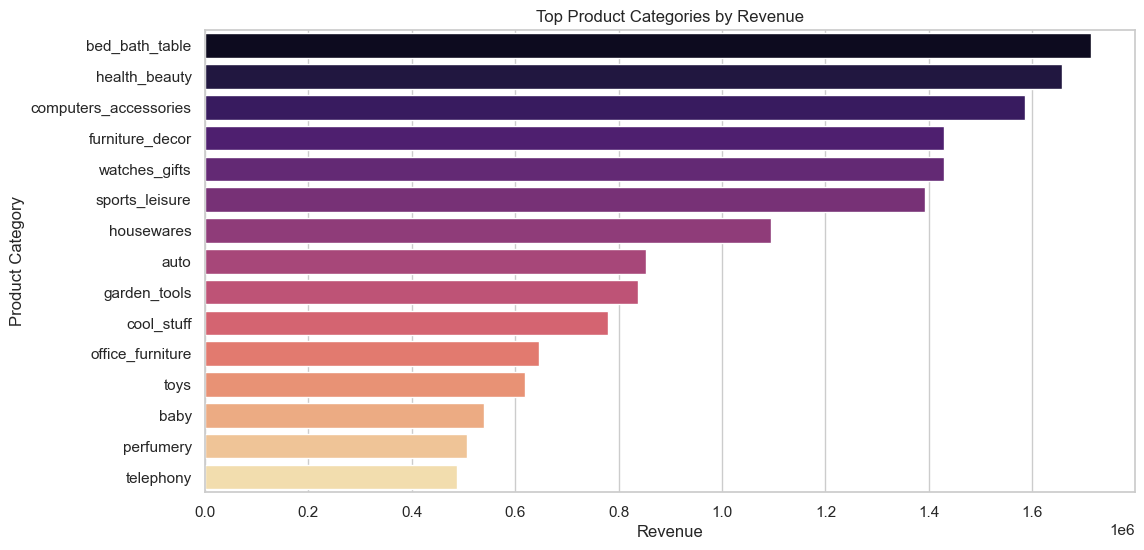

In [17]:

top_categories = (
    order_data
    .groupby("product_category_name_english", as_index=False)
    .agg(
        revenue=("payment_value", "sum"),
        items_sold=("order_item_id", "count"),
        orders=("order_id", "nunique")
    )
    .sort_values("revenue", ascending=False)
    .head(15)
)

display(top_categories)

sns.barplot(
    data=top_categories,
    x="revenue",
    y="product_category_name_english",
    palette="magma"
)

plt.title("Top Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.show()



---------------------------------------------------------------------
Sellers
---------------------------------------------------------------------


In [18]:

top_sellers = (
    order_data
    .groupby("seller_id", as_index=False)
    .agg(
        revenue=("payment_value", "sum"),
        items_sold=("order_item_id", "count"),
        orders=("order_id", "nunique"),
        average_review=("review_score", "mean")
    )
    .sort_values("revenue", ascending=False)
    .head(15)
)

top_sellers


,seller_id,revenue,items_sold,orders,average_review
1535,7c67e1448b00f6e969d365cea6b010ab,507166.91,1364,982,3.341445
192,1025f0e2d44d7041d6cf58b6550e0bfa,308222.04,1428,915,3.853107
881,4a3ca9315b744ce9f8e9374361493884,301245.27,1987,1806,3.803262
368,1f50f920176fa81dab994f9023523100,290253.42,1931,1404,3.987259
1013,53243585a1d6dc2643021fd1853d8905,284903.08,410,358,4.075980
2643,da8622b14eb17ae2831f4ac5b9dab84a,272219.32,1551,1314,4.063754
857,4869f7a5dfa277a7dca6462dcf3b52b2,264166.12,1156,1132,4.122822
1824,955fee9216a65b617aa5c0531780ce60,236322.30,1499,1287,4.050437
3024,fa1c13f2614d7b5c4749cbc52fecda94,206513.23,586,585,4.340206
1560,7e93a43ef30c4f03f38b393420bc753a,185134.21,340,336,4.206490



---------------------------------------------------------------------
Customers and locations
---------------------------------------------------------------------


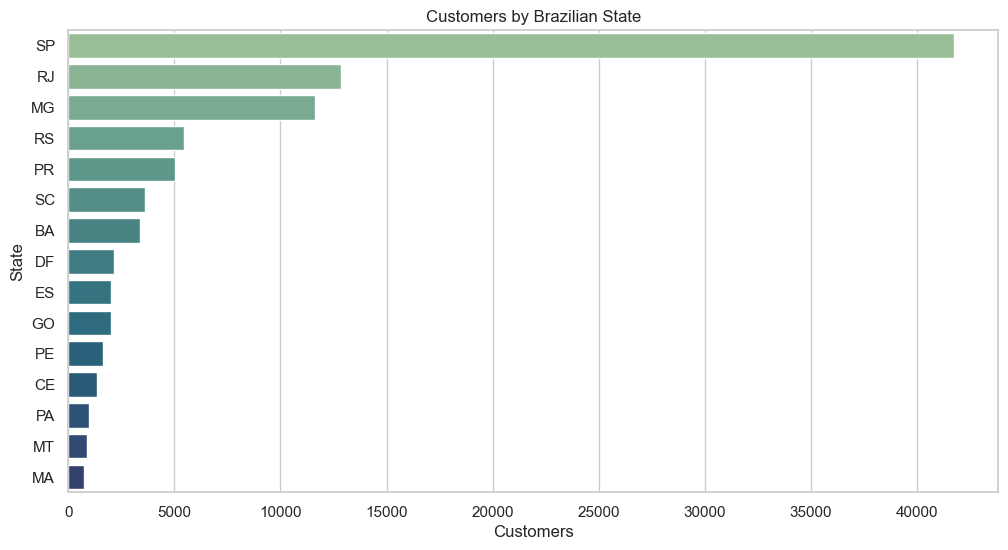

In [19]:

customers_by_state = (
    customers["customer_state"]
    .value_counts()
    .rename_axis("state")
    .reset_index(name="customers")
)

sns.barplot(
    data=customers_by_state.head(15),
    x="customers",
    y="state",
    palette="crest"
)

plt.title("Customers by Brazilian State")
plt.xlabel("Customers")
plt.ylabel("State")
plt.show()



---------------------------------------------------------------------
Payment analysis
---------------------------------------------------------------------


In [ ]:

payment_analysis = (
    order_payments
    .groupby("payment_type", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        payment_count=("payment_type", "count"),
        average_payment=("payment_value", "mean")
    )
    .sort_values("payment_value", ascending=False)
)

display(payment_analysis)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=payment_analysis,
    x="payment_type",
    y="payment_value",
    ax=axes[0],
    palette="Set2"
)

axes[0].set_title("Payment Value by Payment Type")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_xlabel("Payment Type")
axes[0].set_ylabel("Payment Value")

sns.barplot(
    data=payment_analysis,
    x="payment_type",
    y="average_payment",
    ax=axes[1],
    palette="Set3"
)

axes[1].set_title("Average Payment by Payment Type")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_xlabel("Payment Type")
axes[1].set_ylabel("Average Payment")

plt.tight_layout()
plt.show()



---------------------------------------------------------------------
Review analysis
---------------------------------------------------------------------


,review_score,reviews
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


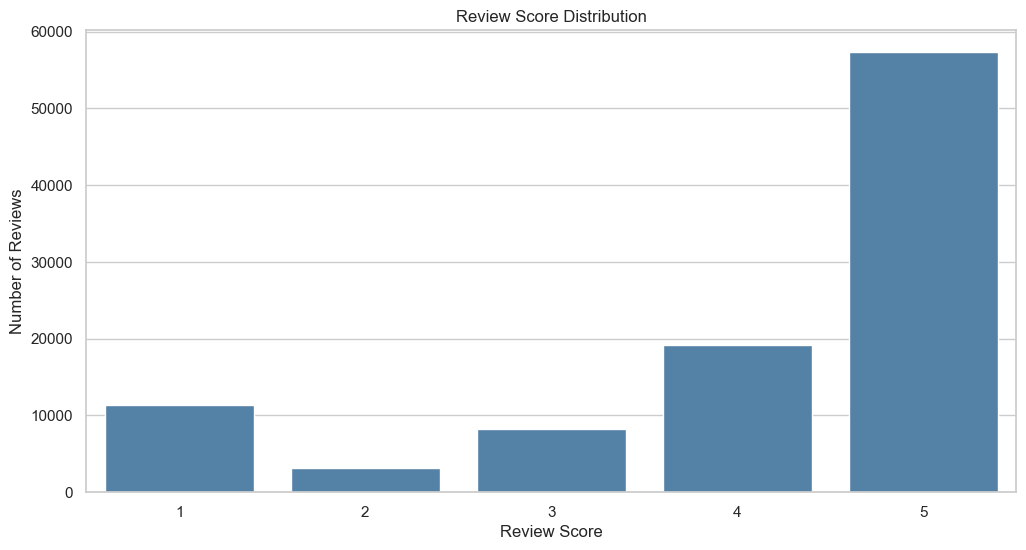

In [20]:

review_distribution = (
    order_reviews["review_score"]
    .value_counts()
    .sort_index()
    .rename_axis("review_score")
    .reset_index(name="reviews")
)

display(review_distribution)

sns.barplot(
    data=review_distribution,
    x="review_score",
    y="reviews",
    color="steelblue"
)

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.show()



---------------------------------------------------------------------
Delivery analysis
---------------------------------------------------------------------


In [21]:

delivered_orders = order_data[
    (order_data["is_delivered"]) &
    (order_data["delivery_days"].notna())
].copy()

delivery_summary = pd.Series({
    "average_delivery_days": delivered_orders["delivery_days"].mean(),
    "median_delivery_days": delivered_orders["delivery_days"].median(),
    "average_delay_days": delivered_orders["delivery_delay_days"].mean(),
    "late_order_percentage": delivered_orders["is_late"].mean() * 100
})

delivery_summary


average_delivery_days    12.472246
median_delivery_days     10.184201
average_delay_days      -11.331987
late_order_percentage     7.908230
dtype: float64

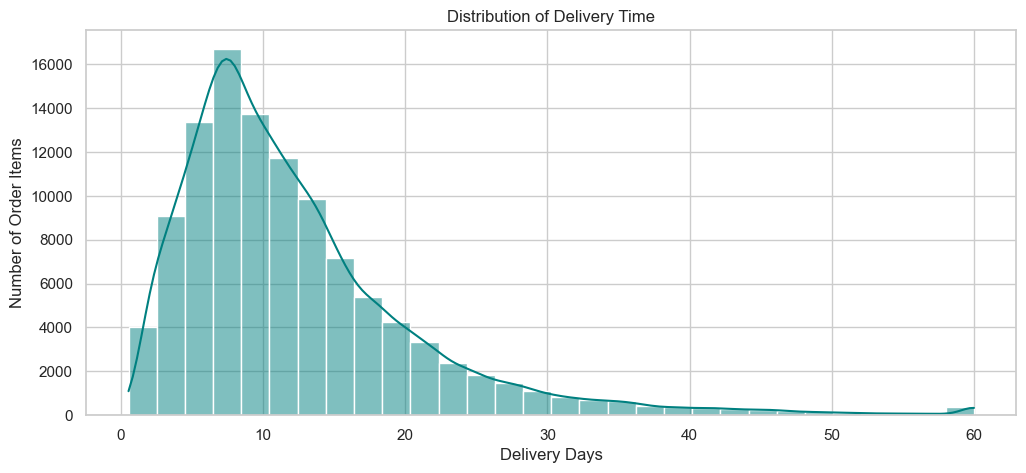

In [22]:

plt.figure(figsize=(12, 5))

sns.histplot(
    delivered_orders["delivery_days"].clip(upper=60),
    bins=30,
    kde=True,
    color="teal"
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Order Items")
plt.show()


In [23]:

delivery_by_state = (
    delivered_orders
    .groupby("customer_state", as_index=False)
    .agg(
        average_delivery_days=("delivery_days", "mean"),
        median_delivery_days=("delivery_days", "median"),
        late_percentage=("is_late", "mean"),
        orders=("order_id", "nunique")
    )
)

delivery_by_state["late_percentage"] *= 100

delivery_by_state.sort_values(
    "average_delivery_days",
    ascending=False
).head(15)


,customer_state,average_delivery_days,median_delivery_days,late_percentage,orders
21,RR,28.231011,24.919144,10.869565,41
3,AP,28.205960,24.094144,4.938272,67
2,AM,26.390967,26.004838,4.294479,145
1,AL,24.489142,22.066007,24.121780,397
13,PA,23.754053,21.042957,12.428843,946
9,MA,21.648667,19.319907,20.375000,717
24,SE,21.467353,17.957245,16.266667,335
5,CE,20.987465,18.088241,15.287518,1279
0,AC,20.715550,18.333623,3.296703,80
14,PB,20.589148,18.361013,11.262799,517



---------------------------------------------------------------------
Correlations
---------------------------------------------------------------------


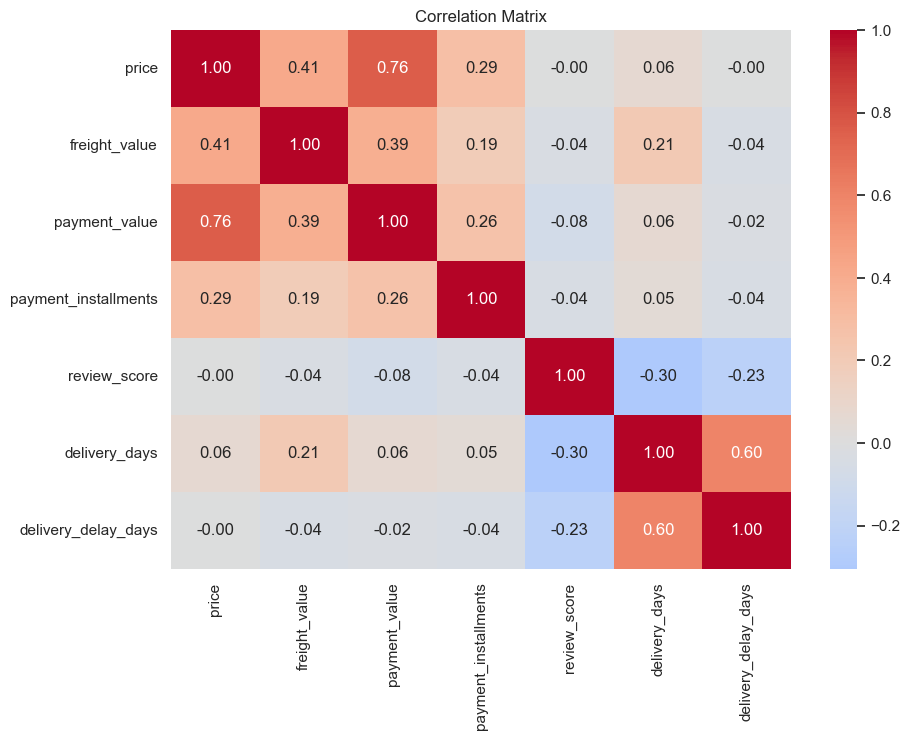

In [24]:

correlation_columns = [
    "price",
    "freight_value",
    "payment_value",
    "payment_installments",
    "review_score",
    "delivery_days",
    "delivery_delay_days"
]

correlation_matrix = order_data[correlation_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()



---------------------------------------------------------------------
RFM-style customer analysis
---------------------------------------------------------------------




Customer value analysis
This section creates a simple RFM-style summary:

Recency: Days since the customer's most recent purchase
Frequency: Number of unique orders
Monetary: Total payment value 

In [25]:

analysis_date = orders["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

customer_summary = (
    order_data
    .groupby("customer_unique_id")
    .agg(
        last_purchase=("order_purchase_timestamp", "max"),
        frequency=("order_id", "nunique"),
        monetary=("payment_value", "sum")
    )
    .reset_index()
)

customer_summary["recency"] = (
    analysis_date - customer_summary["last_purchase"]
).dt.days

customer_summary = customer_summary[
    ["customer_unique_id", "recency", "frequency", "monetary"]
]

customer_summary.sort_values(
    "monetary",
    ascending=False
).head(10)


,customer_unique_id,recency,frequency,monetary
3799,0a0a92112bd4c708ca5fde585afaa872,384,1,109312.64
39443,698e1cf81d01a3d389d96145f7fa6df8,421,1,45256.00
73155,c402f431464c72e27330a67f7b94d4fb,238,1,44048.00
23947,4007669dec559734d6f53e029e360987,328,1,36489.24
89365,ef8d54b3797ea4db1d63f0ced6a906e9,182,1,30186.00
44139,763c8b1c9c68a0229c42c9fc6f662b93,95,1,29099.52
74752,c8460e4251689ba205045f3ea17884a1,71,4,27935.46
87642,eae0a83d752b1dd32697e0e7b4221656,177,2,25051.89
22910,3d47f4368ccc8e1bb4c4a12dbda7111b,381,1,22346.60
64943,adfa1cab2b2c8706db21bb13c0a1beb1,138,1,19457.04



---------------------------------------------------------------------
Export
---------------------------------------------------------------------




Export processed data


In [ ]:

os.makedirs("output", exist_ok=True)

order_data.to_csv(
    "output/olist_order_item_analysis.csv",
    index=False
)

monthly_revenue.to_csv(
    "output/monthly_revenue.csv",
    index=False
)

top_categories.to_csv(
    "output/top_product_categories.csv",
    index=False
)

customer_summary.to_csv(
    "output/customer_rfm_summary.csv",
    index=False
)

print("Processed files exported to the output/ directory.")



---------------------------------------------------------------------
Conclusions
---------------------------------------------------------------------




Suggested business questions
Further analysis could investigate:

Which product categories have the highest profit after freight costs?
Which sellers have high revenue but low review scores?
Does longer delivery time result in lower review scores?
Which customer states produce the greatest revenue?
How many customers make repeat purchases?
Which payment methods are associated with larger orders?
Can late deliveries be predicted using order, seller, product, and location features? 